# Conditional Multimodal VAE — Dummy Tensor Build and Test

This notebook builds and tests a Conditional Multimodal VAE using dummy tensors that mirror the BraTS preprocessing output format.

## What this notebook does
- Builds the encoder (`mu`, `logvar`, sampling) and decoder
- Uses reconstruction MSE + KL divergence loss
- Tests three synthesis setups with dummy tensors
- Runs forward passes and one custom training step per task
- Prints tensor shapes to verify the full pipeline

## Dummy tensor convention
Yue's preprocessing saves slices as **channels-first** `(batch, C, H, W)`.  
This notebook uses `channels_first` throughout to match that convention — no intermediate transposes.

## Summary of fixes applied

| # | Severity | Issue | Fix applied |
|---|----------|-------|-------------|
| 1 | **CRITICAL** | Sigmoid output can't produce z-scored values | `activation=None` (linear) |
| 2 | **CRITICAL** | TF vs PyTorch framework mismatch | Stays TF/Keras; team decision note added |
| 3 | **CRITICAL** | Channel-ordering conversions | `channels_first` globally; transpose removed |
| 4 | MEDIUM | `beta=1e-4` makes KL negligible | `beta=1.0` + `BetaScheduler` annealing |
| 5 | MEDIUM | `latent_dim=64` too small for 240×240 | `latent_dim=128` |
| 6 | MEDIUM | `Flatten+Dense(256)` spatial bottleneck | `GlobalAveragePooling2D` |
| 7 | MEDIUM | No dropout | `Dropout(0.2)` after `enc_dense` and `dec_dense_0` |
| 8 | LOW | Resizing layer masks shape mismatch | Removed; output is exactly 240×240 |
| 9 | LOW | Dummy loader won't match real data | `load_real_data_stub` added |
| 10 | LOW | No LR scheduler | `ReduceLROnPlateau` stub documented |
| 11 | LOW | No gradient clipping | `clipnorm=1.0` on all optimisers |
| 12 | LOW | Task C harder than single-modality | Note added in Task C section |

---
## 1. Imports & Global Setup

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Tuple

# FIX #3 (CRITICAL): Use channels-first globally to match Yue's preprocessing
# output format (4, 240, 240). Eliminates the need for to_channels_last transposes.
tf.keras.backend.set_image_data_format('channels_first')

print("TensorFlow version:", tf.__version__)
print("Image data format :", tf.keras.backend.image_data_format())  # should print 'channels_first'

TensorFlow version: 2.19.0
Image data format : channels_first


> **Framework decision note (FIX #2 — CRITICAL)**  
> This VAE is implemented in **TensorFlow/Keras** (consistent with course material).  
> David's U-Net must also use TensorFlow/Keras for the INT-01 integration pipeline to work without framework-bridging overhead.  
> If the team decides to switch the U-Net to PyTorch, this VAE should be ported at that point.  
> **The decision must be made before Sprint C begins.**

---
## 2. Configuration and Helpers

In [ ]:
@dataclass
class VAEConfig:
    image_size: Tuple[int, int] = (240, 240)
    in_channels: int = 3
    out_channels: int = 1
    latent_dim: int = 128        # FIX #5 (MEDIUM): raised from 64 → 128
    beta: float = 1.0            # FIX #4 (MEDIUM): raised; BetaScheduler handles annealing
    learning_rate: float = 1e-4
    batch_size: int = 2
    encoder_filters: Tuple[int, ...] = (32, 64, 128, 256)
    decoder_filters: Tuple[int, ...] = (256, 128, 64, 32)
    seed: int = 42
    dropout_rate: float = 0.2    # FIX #7 (MEDIUM): dropout for Dense layers


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)


def make_dummy_tensor(batch: int, channels: int = 1,
                      height: int = 240, width: int = 240) -> np.ndarray:
    """Return a random (batch, channels, height, width) float32 tensor."""
    return np.random.rand(batch, channels, height, width).astype(np.float32)


# FIX #9 (LOW): Real-data loading stub
def load_real_data_stub(npz_path: str, target_channel_idx: int):
    """
    Stub showing how to load one slice from Yue's .npz files.

    Yue's preprocessing saves each slice as shape (4, 240, 240):
        channel 0 = T1
        channel 1 = T2
        channel 2 = T1ce
        channel 3 = FLAIR

    To build a synthesis task, drop the target modality channel and keep
    the remaining three as the input.

    Parameters
    ----------
    npz_path : str
        Path to a .npz file produced by Yue's preprocessing script.
    target_channel_idx : int
        Channel index of the modality to synthesise (0–3).

    Returns
    -------
    x : np.ndarray  shape (1, 3, 240, 240)  — input modalities
    y : np.ndarray  shape (1, 1, 240, 240)  — target modality
    """
    data = np.load(npz_path)          # shape (4, 240, 240)
    all_channels = data["slice"]      # adjust key to match Yue's export
    y = all_channels[target_channel_idx : target_channel_idx + 1][np.newaxis]  # (1,1,240,240)
    input_channels = np.delete(all_channels, target_channel_idx, axis=0)       # (3,240,240)
    x = input_channels[np.newaxis]    # (1,3,240,240)
    return x.astype(np.float32), y.astype(np.float32)


# FIX #4 (MEDIUM): Beta annealer
class BetaScheduler:
    """
    Linearly anneals beta from 0.0 to beta_max over `warmup_epochs` epochs.
    Using beta=0 for the first few epochs lets the encoder learn useful
    features before the KL constraint is applied.
    """
    def __init__(self, beta_max: float = 1.0, warmup_epochs: int = 10):
        self.beta_max = beta_max
        self.warmup_epochs = warmup_epochs

    def get(self, epoch: int) -> float:
        if self.warmup_epochs == 0:
            return self.beta_max
        return float(min(self.beta_max, self.beta_max * epoch / self.warmup_epochs))

---
## 3. VAE Architecture

In [ ]:
class Sampling(layers.Layer):
    """Reparameterisation trick: z = mu + sigma * epsilon."""
    def call(self, inputs, training=None):
        mu, logvar = inputs
        eps = tf.random.normal(shape=tf.shape(mu))
        sigma = tf.exp(0.5 * logvar)
        return mu + sigma * eps


def build_encoder(config: VAEConfig):
    """
    Encoder: (B, C, H, W) → mu, logvar, z  each of shape (B, latent_dim).

    FIX #3: input shape is channels-first (C, H, W).
    FIX #6: GlobalAveragePooling2D replaces the Flatten+Dense(256) bottleneck.
    FIX #7: Dropout(0.2) applied after enc_dense.
    """
    h, w = config.image_size
    x_in = keras.Input(shape=(config.in_channels, h, w), name="encoder_input")

    x = x_in
    for i, f in enumerate(config.encoder_filters):
        x = layers.Conv2D(
            f, kernel_size=3, strides=2, padding="same",
            data_format="channels_first",
            name=f"enc_conv_{i}"
        )(x)
        x = layers.BatchNormalization(axis=1, name=f"enc_bn_{i}")(x)
        x = layers.LeakyReLU(negative_slope=0.2, name=f"enc_lrelu_{i}")(x)

    # After 4 stride-2 convolutions on 240×240 → spatial size is 15×15
    x = layers.GlobalAveragePooling2D(data_format="channels_first", name="enc_gap")(x)
    x = layers.Dense(512, activation="relu", name="enc_dense")(x)
    x = layers.Dropout(config.dropout_rate, name="enc_dropout")(x)

    mu     = layers.Dense(config.latent_dim, name="z_mu")(x)
    logvar = layers.Dense(config.latent_dim, name="z_logvar")(x)
    z      = Sampling(name="z_sampling")([mu, logvar])

    return keras.Model(x_in, [mu, logvar, z], name="encoder")


def build_decoder(config: VAEConfig):
    """
    Decoder: z (B, latent_dim) → reconstructed image (B, out_channels, 240, 240).

    FIX #1 (CRITICAL): output activation is None (linear) instead of sigmoid.
        Sigmoid squashes output to [0,1] but z-scored data spans ~ [-3, +4].
        Linear activation lets the decoder produce any real value, required
        for MSE regression on z-scored data.
    FIX #7: Dropout(0.2) applied after dec_dense_0.
    FIX #8: Resizing layer removed. 4 stride-2 transposed convolutions on a
        15×15 feature map produce exactly 240×240 (15→30→60→120→240).
    """
    z_in = keras.Input(shape=(config.latent_dim,), name="z_input")

    x = layers.Dense(512, activation="relu", name="dec_dense_0")(z_in)
    x = layers.Dropout(0.2, name="dec_dropout")(x)
    x = layers.Dense(256 * 15 * 15, activation="relu", name="dec_dense_1")(x)
    x = layers.Reshape((256, 15, 15), name="dec_reshape")(x)

    for i, f in enumerate(config.decoder_filters):
        x = layers.Conv2DTranspose(
            f, kernel_size=3, strides=2, padding="same",
            data_format="channels_first",
            name=f"dec_deconv_{i}"
        )(x)
        x = layers.BatchNormalization(axis=1, name=f"dec_bn_{i}")(x)
        x = layers.LeakyReLU(negative_slope=0.2, name=f"dec_lrelu_{i}")(x)

    # FIX #1: activation=None (linear) — was "sigmoid"
    x = layers.Conv2D(
        config.out_channels, kernel_size=3, padding="same",
        activation=None,
        data_format="channels_first",
        name="decoder_output_conv"
    )(x)

    return keras.Model(z_in, x, name="decoder")


class ConditionalVAE(keras.Model):
    def __init__(self, config: VAEConfig, **kwargs):
        super().__init__(**kwargs)
        self.config  = config
        self.encoder = build_encoder(config)
        self.decoder = build_decoder(config)

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, x, training=False):
        mu, logvar, z = self.encoder(x, training=training)
        recon         = self.decoder(z, training=training)
        return recon, mu, logvar, z

    def compute_losses(self, x, y, training=False, beta: float = None):
        """
        Compute total VAE loss = recon_loss + beta * kl_loss.

        Parameters
        ----------
        beta : float, optional
            Override config.beta (used by BetaScheduler during real training).
            Defaults to config.beta when not supplied.
        """
        if beta is None:
            beta = self.config.beta

        recon, mu, logvar, z = self(x, training=training)

        # MSE reconstruction loss (channels-first: reduce over axes 1,2,3)
        recon_mse  = tf.reduce_mean(tf.math.squared_difference(y, recon), axis=(1, 2, 3))
        recon_loss = tf.reduce_mean(recon_mse)

        kl_per_sample = -0.5 * tf.reduce_sum(
            1.0 + logvar - tf.square(mu) - tf.exp(logvar), axis=1
        )
        kl_loss    = tf.reduce_mean(kl_per_sample)
        total_loss = recon_loss + beta * kl_loss

        return total_loss, recon_loss, kl_loss, recon, mu, logvar, z

    def train_step_batch(self, optimizer, x, y, beta: float = None):
        """One manual gradient update step."""
        if beta is None:
            beta = self.config.beta

        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss, recon, mu, logvar, z = self.compute_losses(
                x, y, training=True, beta=beta
            )

        grads = tape.gradient(total_loss, self.trainable_variables)
        optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss"  : float(total_loss.numpy()),
            "recon_loss"  : float(recon_loss.numpy()),
            "kl_loss"     : float(kl_loss.numpy()),
            "recon_shape" : tuple(recon.shape),
            "mu_shape"    : tuple(mu.shape),
            "logvar_shape": tuple(logvar.shape),
            "z_shape"     : tuple(z.shape),
        }

---
## 4. Create Dummy Tensors (Channels-First)

In [ ]:
set_seed(42)

batch = 2
H, W  = 240, 240

# FIX #3: tensors are channels-first (batch, 1, H, W) — no transpose needed
t1    = make_dummy_tensor(batch, 1, H, W)
t2    = make_dummy_tensor(batch, 1, H, W)
t1ce  = make_dummy_tensor(batch, 1, H, W)
flair = make_dummy_tensor(batch, 1, H, W)

print("Channels-first shapes (batch, C, H, W):")
print("t1   :", t1.shape)
print("t2   :", t2.shape)
print("t1ce :", t1ce.shape)
print("flair:", flair.shape)

Channels-first shapes (batch, C, H, W):
t1   : (2, 1, 240, 240)
t2   : (2, 1, 240, 240)
t1ce : (2, 1, 240, 240)
flair: (2, 1, 240, 240)


---
## 5. Build the Three Synthesis Tasks

In [ ]:
# Task A: synthesise T1ce from T1, T2, FLAIR
X_t1ce  = np.concatenate([t1, t2, flair], axis=1).astype(np.float32)   # (B, 3, 240, 240)
Y_t1ce  = t1ce.astype(np.float32)                                        # (B, 1, 240, 240)

# Task B: synthesise FLAIR from T1, T2, T1ce
X_flair = np.concatenate([t1, t2, t1ce], axis=1).astype(np.float32)
Y_flair = flair.astype(np.float32)

# Task C: synthesise T1 + T2 jointly from T1ce, FLAIR
X_t1t2  = np.concatenate([t1ce, flair], axis=1).astype(np.float32)      # (B, 2, 240, 240)
Y_t1t2  = np.concatenate([t1, t2], axis=1).astype(np.float32)           # (B, 2, 240, 240)

print("Task A  input / output:", X_t1ce.shape,  Y_t1ce.shape)
print("Task B  input / output:", X_flair.shape, Y_flair.shape)
print("Task C  input / output:", X_t1t2.shape,  Y_t1t2.shape)

Task A  input / output: (2, 3, 240, 240) (2, 1, 240, 240)
Task B  input / output: (2, 3, 240, 240) (2, 1, 240, 240)
Task C  input / output: (2, 2, 240, 240) (2, 2, 240, 240)


---
## 6. Task A — T1ce Synthesis (Inputs: T1, T2, FLAIR)

In [ ]:
config_a  = VAEConfig(image_size=(240, 240), in_channels=3, out_channels=1,
                      latent_dim=128, batch_size=batch)
model_a   = ConditionalVAE(config_a)

# FIX #11 (LOW): clipnorm=1.0 prevents gradient explosion from KL spikes
optimizer_a = keras.optimizers.Adam(learning_rate=config_a.learning_rate, clipnorm=1.0)

# FIX #4: BetaScheduler — epoch=10 gives fully warmed-up beta=1.0 for this test
scheduler   = BetaScheduler(beta_max=1.0, warmup_epochs=10)
beta_now    = scheduler.get(epoch=10)

total_loss, recon_loss, kl_loss, recon, mu, logvar, z = model_a.compute_losses(
    X_t1ce, Y_t1ce, training=False, beta=beta_now
)

print("\nTask A — forward pass")
print("  Input shape    :", X_t1ce.shape)
print("  Target shape   :", Y_t1ce.shape)
print("  Recon shape    :", recon.shape)
print("  Mu shape       :", mu.shape)
print("  Logvar shape   :", logvar.shape)
print("  Latent z shape :", z.shape)
print("  Total loss     :", float(total_loss.numpy()))
print("  Recon loss     :", float(recon_loss.numpy()))
print("  KL loss        :", float(kl_loss.numpy()))

train_logs_a = model_a.train_step_batch(optimizer_a, X_t1ce, Y_t1ce, beta=beta_now)
print("\nTask A — one training step:")
print(train_logs_a)


Task A — forward pass
  Input shape    : (2, 3, 240, 240)
  Target shape   : (2, 1, 240, 240)
  Recon shape    : (2, 1, 240, 240)
  Mu shape       : (2, 128)
  Logvar shape   : (2, 128)
  Latent z shape : (2, 128)
  Total loss     : 0.41934823989868164
  Recon loss     : 0.33285894989967346
  KL loss        : 0.08648930490016937

Task A — one training step:
{'total_loss': 8.0973539352417, 'recon_loss': 1.2646915912628174, 'kl_loss': 6.832662582397461, 'recon_shape': (2, 1, 240, 240), 'mu_shape': (2, 128), 'logvar_shape': (2, 128), 'z_shape': (2, 128)}


---
## 7. Task B — FLAIR Synthesis (Inputs: T1, T2, T1ce)

In [ ]:
config_b    = VAEConfig(image_size=(240, 240), in_channels=3, out_channels=1,
                        latent_dim=128, batch_size=batch)
model_b     = ConditionalVAE(config_b)
optimizer_b = keras.optimizers.Adam(learning_rate=config_b.learning_rate, clipnorm=1.0)

total_loss, recon_loss, kl_loss, recon, mu, logvar, z = model_b.compute_losses(
    X_flair, Y_flair, training=False, beta=beta_now
)

print("\nTask B — forward pass")
print("  Input shape    :", X_flair.shape)
print("  Target shape   :", Y_flair.shape)
print("  Recon shape    :", recon.shape)
print("  Mu shape       :", mu.shape)
print("  Logvar shape   :", logvar.shape)
print("  Latent z shape :", z.shape)
print("  Total loss     :", float(total_loss.numpy()))
print("  Recon loss     :", float(recon_loss.numpy()))
print("  KL loss        :", float(kl_loss.numpy()))

train_logs_b = model_b.train_step_batch(optimizer_b, X_flair, Y_flair, beta=beta_now)
print("\nTask B — one training step:")
print(train_logs_b)


Task B — forward pass
  Input shape    : (2, 3, 240, 240)
  Target shape   : (2, 1, 240, 240)
  Recon shape    : (2, 1, 240, 240)
  Mu shape       : (2, 128)
  Logvar shape   : (2, 128)
  Latent z shape : (2, 128)
  Total loss     : 0.35421353578567505
  Recon loss     : 0.3314795196056366
  KL loss        : 0.02273400127887726

Task B — one training step:
{'total_loss': 8.300199508666992, 'recon_loss': 0.9366785287857056, 'kl_loss': 7.363521099090576, 'recon_shape': (2, 1, 240, 240), 'mu_shape': (2, 128), 'logvar_shape': (2, 128), 'z_shape': (2, 128)}


---
## 8. Task C — Joint T1 + T2 Synthesis (Inputs: T1ce, FLAIR)

> **Note (FIX #12):** Task C is harder than single-modality synthesis because the decoder must learn two different modality distributions simultaneously. Expect more training epochs or a larger `latent_dim` compared with Tasks A/B.

In [ ]:
config_c    = VAEConfig(image_size=(240, 240), in_channels=2, out_channels=2,
                        latent_dim=128, batch_size=batch)
model_c     = ConditionalVAE(config_c)
optimizer_c = keras.optimizers.Adam(learning_rate=config_c.learning_rate, clipnorm=1.0)

total_loss, recon_loss, kl_loss, recon, mu, logvar, z = model_c.compute_losses(
    X_t1t2, Y_t1t2, training=False, beta=beta_now
)

print("\nTask C — forward pass")
print("  Input shape    :", X_t1t2.shape)
print("  Target shape   :", Y_t1t2.shape)
print("  Recon shape    :", recon.shape)
print("  Mu shape       :", mu.shape)
print("  Logvar shape   :", logvar.shape)
print("  Latent z shape :", z.shape)
print("  Total loss     :", float(total_loss.numpy()))
print("  Recon loss     :", float(recon_loss.numpy()))
print("  KL loss        :", float(kl_loss.numpy()))

train_logs_c = model_c.train_step_batch(optimizer_c, X_t1t2, Y_t1t2, beta=beta_now)
print("\nTask C — one training step:")
print(train_logs_c)


Task C — forward pass
  Input shape    : (2, 2, 240, 240)
  Target shape   : (2, 2, 240, 240)
  Recon shape    : (2, 2, 240, 240)
  Mu shape       : (2, 128)
  Logvar shape   : (2, 128)
  Latent z shape : (2, 128)
  Total loss     : 0.35706961154937744
  Recon loss     : 0.33415669202804565
  KL loss        : 0.02291293442249298

Task C — one training step:
{'total_loss': 9.510235786437988, 'recon_loss': 1.3956058025360107, 'kl_loss': 8.114629745483398, 'recon_shape': (2, 2, 240, 240), 'mu_shape': (2, 128), 'logvar_shape': (2, 128), 'z_shape': (2, 128)}


---
## 9. Learning-Rate Scheduler Stub (FIX #10)

Uncomment and activate the block below when transitioning from dummy tests to real training.  
`ReduceLROnPlateau` matches the scheduler used by David's U-Net (per INT-04 spec).

In [ ]:
# Uncomment for real training:
#
# lr_callback = keras.callbacks.ReduceLROnPlateau(
#     monitor  = "val_total_loss",
#     factor   = 0.5,
#     patience = 5,
#     min_lr   = 1e-6,
#     verbose  = 1,
# )
#
# Pass to model.fit() or call manually inside a custom training loop:
#   if epoch % check_interval == 0:
#       lr_callback.on_epoch_end(epoch, logs)

print("LR scheduler stub ready — uncomment for real training.")

LR scheduler stub ready — uncomment for real training.


---
## 10. Quick Reconstruction Preview

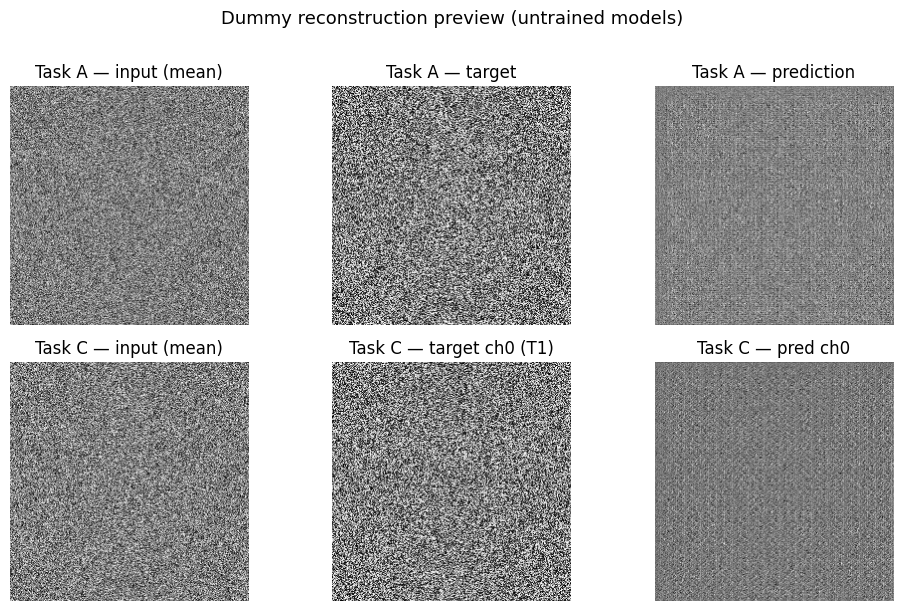

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

pred_a, _, _, _ = model_a(X_t1ce, training=False)
# FIX #3: slice channel dim=1 (channels-first) — not dim=-1
axes[0, 0].imshow(np.mean(X_t1ce[0], axis=0), cmap="gray")   # mean over C axis
axes[0, 0].set_title("Task A — input (mean)")
axes[0, 1].imshow(Y_t1ce[0, 0], cmap="gray")
axes[0, 1].set_title("Task A — target")
axes[0, 2].imshow(pred_a.numpy()[0, 0], cmap="gray")
axes[0, 2].set_title("Task A — prediction")

pred_c, _, _, _ = model_c(X_t1t2, training=False)
axes[1, 0].imshow(np.mean(X_t1t2[0], axis=0), cmap="gray")
axes[1, 0].set_title("Task C — input (mean)")
axes[1, 1].imshow(Y_t1t2[0, 0], cmap="gray")
axes[1, 1].set_title("Task C — target ch0 (T1)")
axes[1, 2].imshow(pred_c.numpy()[0, 0], cmap="gray")
axes[1, 2].set_title("Task C — pred ch0")

for row in axes:
    for ax in row:
        ax.axis("off")

plt.suptitle("Dummy reconstruction preview (untrained models)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Summary

This notebook is a **sanity-check** for the Conditional Multimodal VAE architecture. It verifies:

- ✅ Model builds without error
- ✅ Forward pass succeeds for all three tasks
- ✅ Loss computation (MSE + KL) succeeds
- ✅ One custom gradient training step succeeds
- ✅ Output tensors are exactly `(batch, out_channels, 240, 240)`

Tensors are kept in **channels-first** `(batch, C, H, W)` format throughout, matching Yue's preprocessing output with no intermediate transposes.